# РГР 1

- Автор работы: Сакулин Иван Михайлович, 467335, K3221
- Предмет: Математическая статистика
- Поток: МатСтат 28.3
- Выборка: RGR1_D-14_X1-X4.csv

In [1]:
import matplotlib.pyplot as plt
from scipy.stats import norm, t, chi2
from IPython.display import Math, Markdown, Latex
import math

# Выводы ММ и ММП

##### Нормальное распределение $N_{a, \sigma}$

**Метод моментов**

Для $N_{a, \sigma}$ плотность: $f(x) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{(x-a)^2}{2\sigma^2}}$.

Используем первые два момента: $E[X] = a$ и $E[X^2] = \sigma^2 + a^2$.

Приравниваем их к выборочным моментам:

$a = \bar{X}$

$\sigma^2 + a^2 = \bar{X^2}$

Отсюда выражаем параметры:$$\widehat{a} = \bar{X}, \quad \widehat{\sigma} = \sqrt{\bar{X^2} - (\bar{X})^2} = S$$(где $S$ — выборочное среднеквадратичное отклонение).

**Метод максимального правдоподобия**

Функция правдоподобия для выборки из $n$ элементов:$$f_{a, \sigma}(\vec{X}) = \prod_{i=1}^n \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{(x_i-a)^2}{2\sigma^2}} = (2\pi\sigma^2)^{-n/2} \cdot e^{-\frac{1}{2\sigma^2} \sum (x_i-a)^2}$$

Логарифмируем:$$L_{a, \sigma}(\vec{X}) = -\frac{n}{2}\ln(2\pi) - \frac{n}{2}\ln(\sigma^2) - \frac{1}{2\sigma^2} \sum_{i=1}^n (x_i-a)^2$$

Ищем экстремум по $a$:

$\frac{\partial L}{\partial a} = \frac{1}{\sigma^2} \sum (x_i - a) = 0 \implies \sum x_i - na = 0 \implies \widehat{a} = \bar{X}$

Ищем экстремум по

$\sigma^2$:$\frac{\partial L}{\partial \sigma^2} = -\frac{n}{2\sigma^2} + \frac{1}{2\sigma^4} \sum (x_i - a)^2 = 0 \implies \widehat{\sigma^2} = \frac{1}{n} \sum (x_i - \bar{X})^2$

##### Равномерное распределение $U_{a, b}$

**Метод моментов**

Плотность: $f(x) = \frac{1}{b-a}$ при $x \in [a, b]$.

Моменты: $E[X] = \frac{a+b}{2}$, $D[X] = \frac{(b-a)^2}{12}$.

Система уравнений:$\frac{a+b}{2} = \bar{X} \implies a+b = 2\bar{X}$$\frac{(b-a)^2}{12} = S^2 \implies b-a = \sqrt{12}S = 2\sqrt{3}S$

Складываем и вычитаем уравнения:$$\widehat{a} = \bar{X} - \sqrt{3}S, \quad \widehat{b} = \bar{X} + \sqrt{3}S$$

**Метод максимального правдоподобия**

Функция правдоподобия: $$f_{a, b}(\vec{X}) = \prod_{i=1}^n \frac{1}{b-a} = \frac{1}{(b-a)^n}$$ при условии, что $a \le x_{(1)}$ и $b \ge x_{(n)}$ (где $x_{(1)}$ и $x_{(n)}$ — края вариационного ряда).

Чтобы максимизировать дробь $\frac{1}{(b-a)^n}$, нужно минимизировать знаменатель $(b-a)$.

Минимально возможное значение для $b$ — это $x_{(n)}$, максимально возможное для $a$ — это $x_{(1)}$.

Отсюда оценки ММП: $$\widehat{a} = x_{(1)}, \quad \widehat{b} = x_{(n)}$$

##### Экспоненциальное распределение со сдвигом $Exp_{\lambda, c}$

**Метод моментов**

Для $Exp_{\lambda, c}$ плотность имеет вид $f(x) = \lambda e^{-\lambda(x-c)}$ при $x \ge c$.

Найдем первый и второй моменты (через замену $u = x-c$):$E[X] = \int_c^{+\infty} x \lambda e^{-\lambda(x-c)} dx = c + \frac{1}{\lambda}$$D[X] = \frac{1}{\lambda^2} \implies E[X^2] = (c + \frac{1}{\lambda})^2 + \frac{1}{\lambda^2}$

Приравниваем к выборочным характеристикам ($\bar{X}$ и $S^2$):$c + \frac{1}{\lambda} = \bar{X} \implies \frac{1}{\lambda} = \bar{X} - c$$\frac{1}{\lambda^2} = S^2 \implies \lambda = \frac{1}{S}$

Отсюда выражаем параметры: $$\widehat{\lambda} = \frac{1}{S}, \quad \widehat{c} = \bar{X} - S$$

**Метод максимального правдоподобия**

Функция правдоподобия при условии $x_i \ge c$:$$f_{\lambda, c}(\vec{X}) = \prod_{i=1}^n \lambda e^{-\lambda(x_i-c)} = \lambda^n e^{-\lambda (\sum x_i - nc)}$$

Логарифмируем: $$L_{\lambda, c}(\vec{X}) = n\ln\lambda - \lambda (\sum x_i - nc)$$Для $c$:

Чтобы максимизировать $L$, нужно минимизировать выражение $(\sum x_i - nc)$. Это достигается при максимально возможном $c$.

Так как по условию $c \le x_i$ для всех $i$, то:$$\widehat{c} = x_{(1)} = \min(X)$$Для $\lambda$: ищем экстремум, зная найденный $\widehat{c}$:

$$\frac{\partial L}{\partial \lambda} = \frac{n}{\lambda} - (\sum x_i - n\widehat{c}) = 0$$

$$\frac{n}{\lambda} = n\bar{X} - n\widehat{c} \implies \widehat{\lambda} = \frac{1}{\bar{X} - \widehat{c}}$$

# Реализация алгоритмов

Вариационный ряд и эмпирическая функцию распределения $F_n(x)$

In [2]:
def CDF(X: list) -> tuple[list, list]:
  CDF_x = []
  cum_counts = []
  counter = 0

  for i, x in enumerate(X):
      counter += 1
      if i + 1 == n or X[i+1] != x:
          CDF_x.append(x)
          cum_counts.append(counter)
  CDF_y = [c / n for c in cum_counts]
  return CDF_x, CDF_y

def CDF_display(X: list):
  CDF_x, CDF_y = CDF(X)

  plt.figure(figsize=(6, 4))
  plt.scatter(CDF_x, CDF_y, s=1)
  plt.hlines(CDF_y[:-1], CDF_x[:-1], CDF_x[1:])

  plt.xlabel('x', fontsize=12)
  plt.ylabel('F_n(x)', fontsize=12)
  plt.title('Эмпирическая функция распределения', fontsize=14)
  plt.grid(True, linestyle='--', alpha=0.6)
  plt.ylim(-0.05, 1.05)

  plt.show()

Числовые характеристики: выборочное среднее $\bar{x}$, дисперсия (смещённая) $S^2$, дисперсия (несмещённая) $\hat{σ}^2$, стандартные отклонения $S$ и $\hat{σ}$, медиана $m_e$ и квантили (в том числе квартили)

In [3]:
def mean(X):
  return sum(X) / len(X)

def var(X, biased: bool):
  offset = (0 if biased else 1)
  return sum([(mean(X) - x)**2 for x in X]) / (len(X) - offset)

def std(X, biased: bool):
  return (var(X, biased))**0.5

def quantile(X: list, q):
  n = len(X)
  pos = q * (n - 1)
  idx = int(pos)
  frac = pos - idx
  if idx + 1 < n:
    return X[idx] * (1 - frac) + X[idx + 1] * frac
  return X[idx]

def median(X: list):
  return quantile(X, 0.5)

In [4]:
def characteristics(X):
  X_mean = mean(X)
  S2 = var(X, True)
  S = std(X, True)
  Sigma2 = var(X, False)
  Sigma = std(X, False)
  Q1 = quantile(X, 0.25)
  me = median(X)
  Q3 = quantile(X, 0.25)

  mu2 = sum((x - X_mean)**2 for x in X) / n
  mu3 = sum((x - X_mean)**3 for x in X) / n
  mu4 = sum((x - X_mean)**4 for x in X) / n
  As = mu3 / (mu2**1.5)
  Ek = mu4 / (mu2**2) - 3

  display(Math(f"\\bar{{X}} = {X_mean}"))
  display(Math(f"S^2 = {S2:.3f}, \\quad S = {S:.3f}"))
  display(Math(f"\\sigma^2 = {Sigma2:.3f}, \\quad \\sigma = {Sigma:.3f}"))
  display(Math(f"m_e = {me}"))
  display(Math(f"Q_{{0.25}} = {Q1}, \\quad Q_{{0.75}} = {Q3}"))

  display(Math(f"A_s = {As:.4f}"))
  display(Math(f"E_k = {Ek:.4f}"))

Правила разбиения для гистограм (результат - ширина интервала)

In [5]:
def sturges_rule(X):
  return 1 + math.floor(math.log2(len(X)))

def scott_rule(X):
  n = len(X)
  s = std(X, True)
  h = 3.5 * s / (n ** (1/3))
  return max(1, int(math.ceil(max(X) - min(X) / h)))

def fd_rule(X):
  n = len(X)
  iqr = quantile(X, 0.75) - quantile(X, 0.25)
  h = 2 * iqr / (n ** (1/3))
  return max(1, int(math.ceil(max(X) - min(X) / h)))

Постройка нескольких гистограмм с разными правилами

In [6]:
def histogram(X):
  methods = [
    ("Стерджес", sturges_rule),
    ("Скотт", scott_rule),
    ("Фридман–Диаконис", fd_rule)
  ]

  plt.figure(figsize=(12, 4))

  for i, (name, rule_func) in enumerate(methods, start=1):
    plt.subplot(1, 3, i)
    bins = rule_func(X)
    plt.hist(X, bins=bins, edgecolor='black', alpha=0.7)
    plt.title(name)

  plt.suptitle(f'Гистограммы')
  plt.tight_layout()
  plt.show()

Boxplot

In [7]:
def draw_boxplot(X):
    plt.figure(figsize=(6, 4))
    plt.boxplot(X)
    plt.title('Boxplot')
    plt.ylabel('Значения')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

Оценивание ММ и ММП

In [8]:
def estimation_normal(X):
  a_mm = mean(X)
  s_mm = std(X, True)
  display(Markdown(f"Метод моментов: $a = {a_mm:.4f}, σ = {s_mm:.4f}$"))

  a_mle = mean(X)
  s_mle = std(X, True)
  display(Markdown(f"ММП: $a = {a_mle:.4f}, σ = {s_mle:.4f}$"))

  a_delta = abs(a_mle - a_mm)
  s_delta = abs(s_mle - s_mm)
  display(Markdown(f"Различие: $Δa = {a_delta:.4f}, Δσ = {s_delta:.4f}$"))

In [9]:
def estimation_uniform(X):
  xbar = mean(X)
  s2 = var(X, True)
  a_mm = xbar - math.sqrt(3 * s2)
  b_mm = xbar + math.sqrt(3 * s2)
  display(Markdown(f"Метод моментов: $a = {a_mm:.4f}, b = {b_mm:.4f}$"))

  a_mle = min(X)
  b_mle = max(X)
  display(Markdown(f"ММП: $a = {a_mle:.4f}, b = {b_mle:.4f}$"))

  a_delta = abs(a_mle - a_mm)
  b_delta = abs(b_mle - b_mm)
  display(Markdown(f"Различие: $Δa = {a_delta:.4f}, Δb = {b_delta:.4f}$"))

In [10]:
def estimation_exp(X):
  s = std(X, True)
  l_mm = 1.0 / s if s != 0 else 1e-6
  c_mm = mean(X) - 1.0 / l_mm
  display(Markdown(f"Метод моментов: $λ = {l_mm:.4f}, c = {c_mm:.4f}$"))

  c_mle = min(X)
  l_mle = 1.0 / (mean(X) - c_mle) if mean(X) > c_mle else 1e-6
  display(Markdown(f"ММП: $λ = {l_mle:.4f}, c = {c_mle:.4f}$"))

  c_delta = abs(c_mle - c_mm)
  l_delta = abs(l_mle - l_mm)
  display(Markdown(f"Различие: $Δλ = {l_delta:.4f}, Δc = {c_delta:.4f}$"))

Оценивание параметрической вероятности

In [11]:
def prob_normal(X, x0=None):
  if x0 is None:
    x0 = mean(X) + std(X, False)
  display(Math(f"x_0 = {x0:.4f}"))

  emp_prob = sum(1 for xi in X if xi > x0) / len(X)
  display(Markdown(f"Эмпирическая вероятность: $\\hat{{P}}(X > x_0) = {emp_prob:.4f}$"))

  mu = mean(X)
  sigma = std(X, True)
  z = (x0 - mu) / (sigma * math.sqrt(2)) if sigma > 0 else float('inf')
  param_prob = 0.5 * math.erfc(z)  # 1 - Ф(z)
  display(Markdown(f"Параметрическая вероятность (нормальное): $P(X > x_0) = {param_prob:.4f}$"))

  display(Markdown(f"Расхождение: ${abs(emp_prob - param_prob):.4f}$"))


In [12]:
def prob_uniform(X, x0=None):
  if x0 is None:
    x0 = mean(X) + std(X, False)
  display(Math(f"x_0 = {x0:.4f}"))

  emp_prob = sum(1 for xi in X if xi > x0) / len(X)
  display(Markdown(f"Эмпирическая вероятность: $\\hat{{P}}(X > x_0) = {emp_prob:.4f}$"))

  a = min(X)
  b = max(X)
  if x0 <= a:
    param_prob = 1.0
  elif x0 >= b:
    param_prob = 0.0
  else:
    param_prob = (b - x0) / (b - a)
  display(Markdown(f"Параметрическая вероятность (равномерное): $P(X > x_0) = {param_prob:.4f}$"))

  display(Markdown(f"Расхождение: ${abs(emp_prob - param_prob):.4f}$"))

In [13]:
def prob_exp(X, x0=None):
  if x0 is None:
    x0 = mean(X) + std(X, False)
  display(Math(f"x_0 = {x0:.4f}"))

  emp_prob = sum(1 for xi in X if xi > x0) / len(X)
  display(Markdown(f"Эмпирическая вероятность: $\\hat{{P}}(X > x_0) = {emp_prob:.4f}$"))

  c = min(X)
  mean_x = mean(X)
  if mean_x > c:
    lam = 1.0 / (mean_x - c)
  else:
    lam = 1e-6  # защита от 0 знаменателя

  if x0 <= c:
    param_prob = 1.0
  else:
    param_prob = math.exp(-lam * (x0 - c))
  display(Markdown(f"Параметрическая вероятность (экспоненциальное): $P(X > x_0) = {param_prob:.4f}$"))

  display(Markdown(f"Расхождение: ${abs(emp_prob - param_prob):.4f}$"))

Оценка моментов по сгруппированной выборке

In [14]:
def grouped_moments(X, rule='sturges'):
  n = len(X)
  if isinstance(rule, int):
    bins = rule
  elif rule == 'sturges':
    bins = sturges_rule(X)
  elif rule == 'scott':
    bins = scott_rule(X)
  elif rule == 'fd':
    bins = fd_rule(X)
  else:
    raise ValueError("rule must be 'sturges', 'scott' or 'fd'")
  display(Markdown(f"Правило группировки: {rule}, число интервалов $m = {bins}$"))

  # делим на интервалы
  x_min = min(X)
  x_max = max(X)
  width = (x_max - x_min) / bins
  edges = [x_min + i * width for i in range(bins + 1)]

  counts = [0] * bins
  mids = [(edges[i] + edges[i+1]) / 2 for i in range(bins)]

  # распределяем значения по интервалам
  for val in X:
    idx = int((val - x_min) // width)
    if idx >= bins:
      idx = bins - 1
    counts[idx] += 1

  # по группам
  X_g = sum(cnt * mid for cnt, mid in zip(counts, mids)) / n
  var_g = sum(cnt * (mid - X_g) ** 2 for cnt, mid in zip(counts, mids)) / (n - 1)
  display(Math(f"\\hat{{X}}_g = {X_g:.4f}, \\quad \\hat{{\\sigma}}_g^2 = {var_g:.4f}"))

  # по исходным данным
  X_orig = mean(X)
  var_orig = var(X, False)
  display(Math(f"\\bar{{X}} = {X_orig:.4f}, \\quad \\hat{{\\sigma}}^2 = {var_orig:.4f}"))

  display(Math(f"\\Delta \\bar{{X}} = {abs(X_g - X_orig):.4f}, \\quad \\Delta \\hat{{\\sigma}}^2 = {abs(var_g - var_orig):.4f}"))

In [15]:
def asy_ci_mean(X, alpha=0.05):
  n = len(X)
  xbar = mean(X)
  sigma_hat = std(X, False)
  z = norm.ppf(1 - alpha/2)
  margin = z * sigma_hat / math.sqrt(n)
  lower = xbar - margin
  upper = xbar + margin

  display(Markdown(f"Асимптотический $(\\alpha = {1-alpha})$ ДИ для EX:"))
  display(Math(f"({lower:.4f}, \\; {upper:.4f})"))

In [16]:
def exact_ci_normal(X, alpha=0.05):
    n = len(X)
    xbar = mean(X)
    sigma_hat = std(X, False)

    # доверительный интервал для μ
    t_quant = t.ppf(1 - alpha/2, df=n-1)
    margin_mu = t_quant * sigma_hat / math.sqrt(n)
    mu_lower = xbar - margin_mu
    mu_upper = xbar + margin_mu

    # доверительный интервал для σ²
    chi2_low = chi2.ppf(alpha/2, df=n-1)
    chi2_high = chi2.ppf(1 - alpha/2, df=n-1)
    var_lower = (n-1) * sigma_hat**2 / chi2_high
    var_upper = (n-1) * sigma_hat**2 / chi2_low

    display(Markdown(f"Точный $(\\alpha = {1-alpha})$ ДИ для $\\mu$ (неизвестный $\\sigma^2$):"))
    display(Math(f"({mu_lower:.4f}, \\; {mu_upper:.4f})"))
    display(Markdown(f"Точный $(\\alpha = {1-alpha})$ ДИ для $\\sigma^2$:"))
    display(Math(f"({var_lower:.4f}, \\; {var_upper:.4f})"))


# Основное задание

In [17]:
from pandas import read_csv
df = read_csv('https://drive.usercontent.google.com/u/0/uc?id=1lMUvcOZTU21CprdBKlgIzv6pp8O2FqXV&export=download')
X1 = df['X1'].to_list()
X2 = df['X2'].to_list()
X3 = df['X3'].to_list()
X4 = df['X4'].to_list()

### $X_1$

##### 1. Первичное описание выборки

In [18]:
X = sorted(X1)
n = len(X)
print('Объём выборки', n)
print('Вариационный ряд', X)

Объём выборки 200
Вариационный ряд [28.11, 28.73, 28.78, 28.83, 28.88, 29.2, 30.53, 31.59, 31.64, 32.58, 33.23, 33.38, 33.89, 34.05, 34.11, 34.8, 35.17, 35.24, 35.3, 36.49, 36.79, 36.85, 37.38, 37.39, 37.43, 37.78, 38.38, 38.5, 38.96, 39.03, 39.36, 40.12, 40.4, 40.86, 41.47, 42.7, 42.73, 42.91, 42.92, 43.52, 44.68, 45.82, 46.48, 46.77, 46.84, 47.18, 47.34, 48.01, 48.27, 48.31, 48.52, 48.73, 48.76, 48.95, 49.17, 49.34, 50.07, 50.12, 50.92, 51.33, 52.27, 52.59, 53.29, 53.41, 54.26, 54.29, 55.25, 56.01, 56.69, 57.01, 57.14, 57.97, 59.31, 59.62, 60.2, 60.67, 61.0, 61.63, 61.65, 61.88, 61.94, 62.49, 62.87, 63.09, 63.09, 63.17, 63.31, 64.35, 64.63, 65.07, 65.15, 65.43, 65.64, 65.74, 65.94, 66.35, 66.51, 66.58, 66.68, 68.64, 69.85, 70.05, 70.23, 70.29, 71.31, 72.09, 73.24, 73.29, 73.44, 73.5, 73.8, 74.21, 74.37, 74.37, 74.49, 74.56, 75.18, 75.21, 75.45, 75.92, 75.97, 76.18, 77.33, 77.37, 78.02, 79.21, 79.35, 79.62, 79.77, 80.19, 80.32, 80.46, 80.64, 81.56, 83.28, 83.45, 83.88, 83.93, 84.48, 8

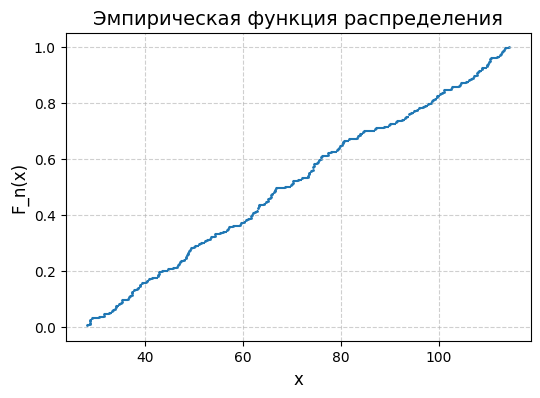

In [19]:
CDF_display(X)

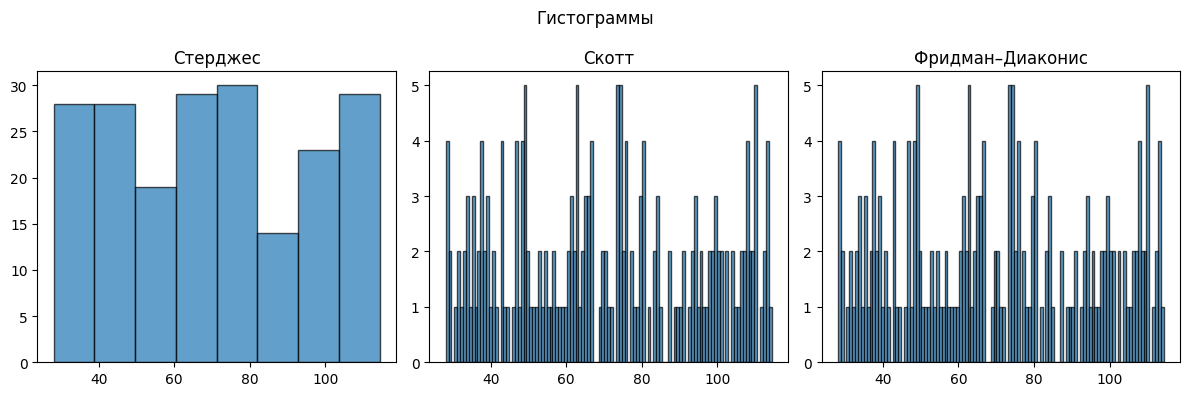

In [20]:
histogram(X)

In [21]:
characteristics(X)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

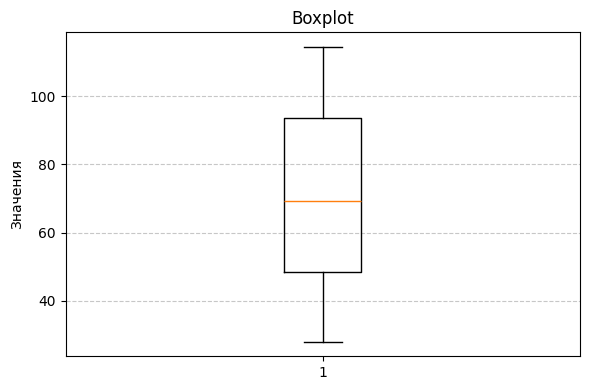

In [22]:
draw_boxplot(X)

Описание формы распределения:
- Распределение выглядит практически симметричным. Выборочное среднее ($\bar{X} \approx 70.29$) и медиана ($m_e \approx 69.25$) находятся очень близко друг к другу.
- Все значения укладываются в границы усов, выбросы и хвосты отсутствуют.
- У выборки наблюдаются четкие естественные границы (примерно от 28 до 114).

##### 2. Предположение о виде закона распределения

Лучшая модель для $X_1$ - **равномерное распределение $U_{a,b}$.**

По гистаграммам, в большей степени по правилам разбиению Стерждеса, видны прямоугольные очертания без пика в центре. ЭФР больше похожа на наклонную линию, что говорит о равномерном увеличении количества значений при равномерном увеличении отрезка. Отсутствие хвостов-выбросов исключает нормальное распределение. Отсутствие концентрации значений слева исключает экспотенциальное.

##### 3. Оценивание параметров: метод моментов и метод максимального правдоподобия

In [23]:
estimation_uniform(X)

Метод моментов: $a = 26.2710, b = 114.3073$

ММП: $a = 28.1100, b = 114.3400$

Различие: $Δa = 1.8390, Δb = 0.0327$

ММП «точнее» схватил границы интервала ($28.1$ и $114.3$), так как он ориентируется на крайние точки, в то время как метод моментов немного промахнулся из-за разряженных данных слева.

##### 4. Оценивание параметрической вероятности двумя способами

In [24]:
prob_uniform(X)

<IPython.core.display.Math object>

Эмпирическая вероятность: $\hat{P}(X > x_0) = 0.2250$

Параметрическая вероятность (равномерное): $P(X > x_0) = 0.2154$

Расхождение: $0.0096$

Минимальное расхождение, что логично для равномерного распределения.

##### 5. Оценка моментов по сгруппированной выборке

In [25]:
grouped_moments(X)

Правило группировки: sturges, число интервалов $m = 8$

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Упаковка данных в 8 интервалов прошла почти бесследно: среднее изменилось незначительно.

##### 6. Доверительные интервалы

In [26]:
asy_ci_mean(X)

Асимптотический $(\alpha = 0.95)$ ДИ для EX:

<IPython.core.display.Math object>

Полученный интервал означает, что процедура его построения в 95% случаев гарантирует «накрытие» истинного математического ожидания генеральной совокупности. Это прогноз, что в 95% случаев при повторении опыта среднее окажется в том же интервале.

### $X_2$

##### 1. Первичное описание выборки

In [27]:
X = sorted(X2)
n = len(X)
print('Объём выборки', n)
print('Вариационный ряд', X)

Объём выборки 200
Вариационный ряд [9.2, 9.29, 9.52, 9.62, 9.65, 9.72, 9.81, 9.82, 9.89, 9.9, 10.0, 10.23, 10.38, 10.4, 10.56, 10.62, 10.71, 10.73, 10.99, 11.27, 11.29, 11.35, 11.37, 11.37, 11.38, 11.45, 11.46, 11.52, 11.6, 11.85, 12.54, 12.69, 12.71, 13.0, 13.1, 13.11, 13.18, 13.28, 13.41, 13.43, 13.52, 13.55, 13.69, 13.75, 13.8, 13.82, 14.12, 14.31, 14.44, 14.59, 14.66, 14.67, 14.95, 15.5, 15.51, 15.56, 15.56, 15.79, 15.86, 16.01, 16.07, 16.11, 16.18, 16.34, 16.36, 16.67, 16.84, 17.06, 17.14, 17.55, 17.58, 17.95, 17.97, 18.41, 18.65, 18.79, 19.32, 19.34, 19.41, 19.56, 19.62, 19.68, 19.68, 19.72, 19.95, 20.14, 20.45, 20.53, 20.57, 21.15, 21.19, 21.33, 21.41, 21.8, 21.87, 21.89, 22.46, 22.55, 22.88, 23.01, 23.63, 23.92, 24.63, 24.74, 24.75, 25.37, 25.63, 26.33, 26.75, 27.15, 27.49, 27.54, 27.59, 28.12, 29.03, 29.19, 29.5, 29.55, 29.58, 30.52, 30.6, 30.85, 32.2, 32.31, 32.53, 32.64, 32.95, 33.35, 33.4, 33.56, 33.83, 34.28, 34.69, 34.71, 35.04, 35.35, 35.78, 36.12, 36.39, 36.43, 36.44, 3

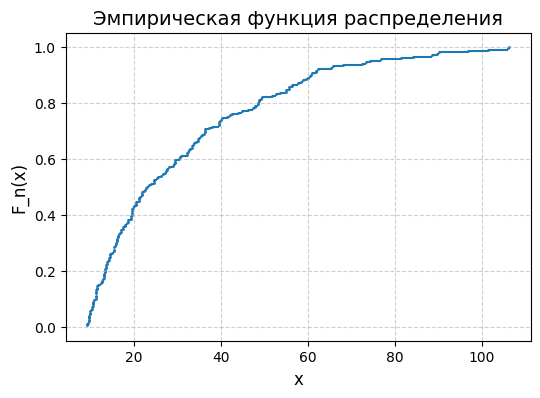

In [28]:
CDF_display(X)

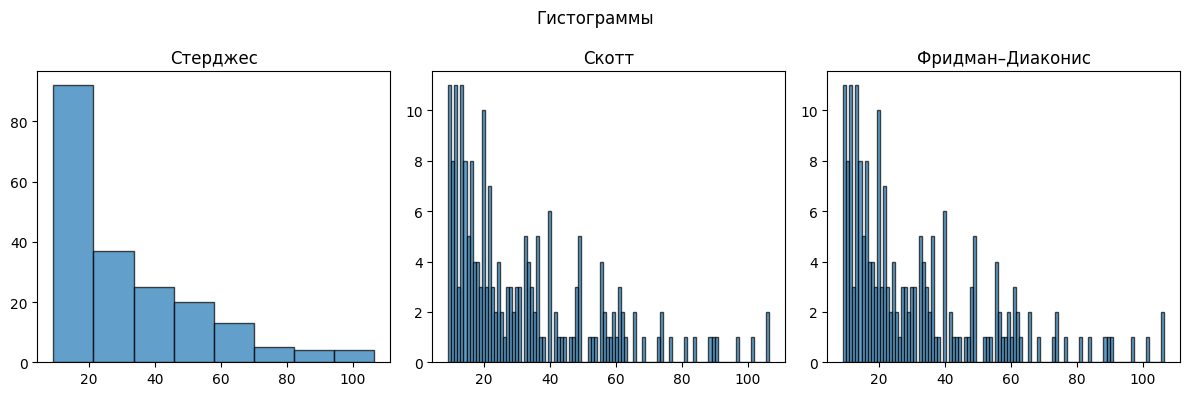

In [29]:
histogram(X)

In [30]:
characteristics(X)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

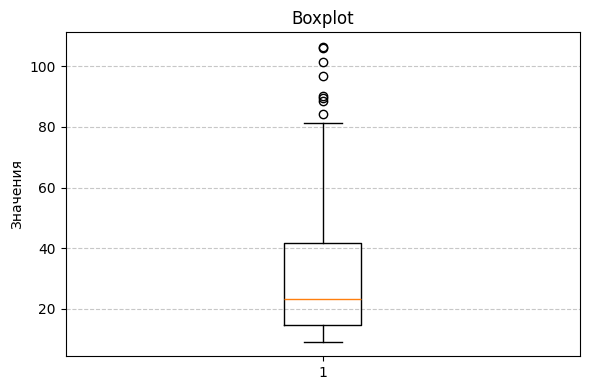

In [31]:
draw_boxplot(X)

Описание формы распределения:
- Основная масса данных сгруппирована слева, а график плавно уходит вправо: правосторонняя (положительная) ассиметрия.
- На boxplot видна целая серия выбросов выше значения 80 (справа)
- У выборки есть жесткая нижняя граница (около $9.2$), ниже которой значений нет, а вот верхняя граница размыта.

##### 2. Предположение о виде закона распределения

Лучшая модель для $X_2$ - **экспоненциальное распределение со сдвигом $Exp_{\lambda, c}$.**

Гистограмма показывает характерный «обрыв» слева и плавное затухание вправо, что идеально ложится в экспоненциальную кривую. Эмпирическая функция распределения (ЭФР) быстро растет в начале и медленно приближается к единице в конце, повторяя теоретический вид $1 - e^{-\lambda(x-c)}$. Большое количество выбросов на boxplot подтверждает наличие редких, но очень больших значений, типичных для этого закона.

##### 3. Оценивание параметров: метод моментов и метод максимального правдоподобия

In [32]:
estimation_exp(X)

Метод моментов: $λ = 0.0462, c = 9.7656$

ММП: $λ = 0.0451, c = 9.2000$

Различие: $Δλ = 0.0012, Δc = 0.5656$

ММП и ММ разошлись в оценке сдвига $c$, так как ММП просто взял самое маленькое число в выборке, а метод моментов смотрел на всю группу с правым хвостом.

##### 4. Оценивание параметрической вероятности двумя способами

In [33]:
prob_exp(X)

<IPython.core.display.Math object>

Эмпирическая вероятность: $\hat{P}(X > x_0) = 0.1700$

Параметрическая вероятность (экспоненциальное): $P(X > x_0) = 0.1385$

Расхождение: $0.0315$

Разница в 0.0315 между теорией и практикой показывает, что экспоненциальная модель чуть-чуть недобрала — в хвосте оказалось на $3\%$ больше значений, чем предсказала формула.

##### 5. Оценка моментов по сгруппированной выборке

In [34]:
grouped_moments(X, 'scott')

Правило группировки: scott, число интервалов $m = 106$

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Группировка по Скотту и Фридману–Диаконису даёт неплохие результаты, так как разбивает на большее количество интервалов.

##### 6. Доверительные интервалы

In [35]:
asy_ci_mean(X)

Асимптотический $(\alpha = 0.95)$ ДИ для EX:

<IPython.core.display.Math object>

Полученный интервал означает, что процедура его построения в 95% случаев гарантирует «накрытие» истинного математического ожидания генеральной совокупности. Это прогноз, что в 95% случаев при повторении опыта среднее окажется в том же интервале.

### $X_3$

##### 1. Первичное описание выборки

In [36]:
X = sorted(X3)
n = len(X)
print('Объём выборки', n)
print('Вариационный ряд', X)

Объём выборки 200
Вариационный ряд [72.4, 73.64, 76.3, 76.75, 78.76, 79.06, 79.19, 79.58, 79.8, 79.84, 80.64, 81.17, 81.27, 81.43, 81.63, 83.05, 83.41, 83.7, 83.81, 83.84, 84.44, 84.94, 85.31, 85.46, 85.48, 85.69, 85.92, 86.1, 86.11, 86.27, 86.3, 86.42, 86.43, 86.53, 86.68, 86.73, 86.78, 86.85, 86.93, 87.1, 87.11, 87.29, 87.48, 87.57, 87.77, 87.83, 87.99, 88.19, 88.29, 88.3, 88.43, 88.63, 88.7, 88.72, 88.72, 88.91, 88.93, 89.04, 89.25, 89.3, 89.38, 89.52, 89.71, 89.78, 89.8, 89.92, 90.2, 90.27, 90.31, 90.38, 90.57, 90.81, 90.93, 90.96, 91.04, 91.07, 91.14, 91.19, 91.25, 91.67, 91.71, 91.95, 91.96, 91.96, 91.97, 91.99, 92.0, 92.09, 92.14, 92.23, 92.49, 92.64, 92.88, 92.9, 92.93, 92.99, 93.05, 93.14, 93.14, 93.25, 93.28, 93.3, 93.33, 93.33, 93.35, 93.35, 93.52, 93.58, 93.64, 93.66, 93.73, 93.77, 93.81, 93.87, 93.9, 94.02, 94.03, 94.1, 94.12, 94.25, 94.34, 94.38, 94.5, 94.57, 94.72, 94.82, 94.98, 95.22, 95.5, 95.65, 95.95, 96.08, 96.15, 96.24, 96.64, 96.78, 96.88, 97.5, 97.51, 97.56, 97.6

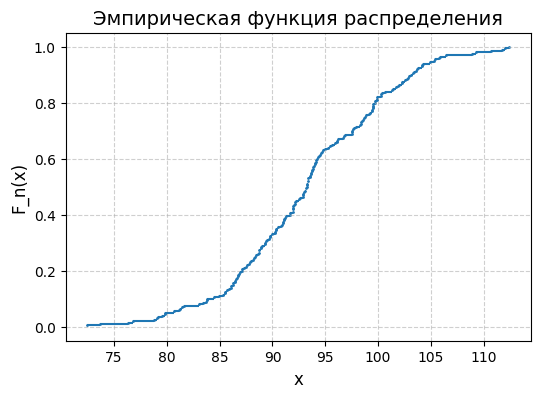

In [37]:
CDF_display(X)

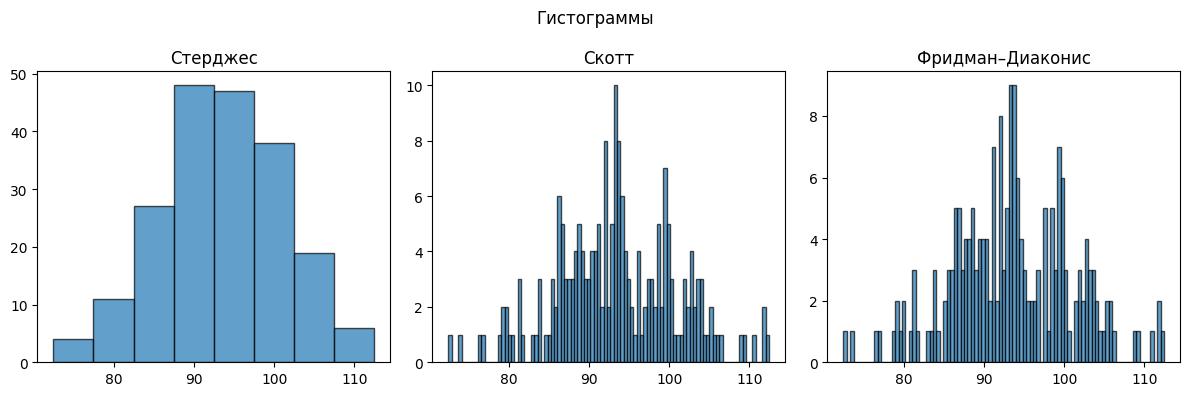

In [38]:
histogram(X)

In [39]:
characteristics(X)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

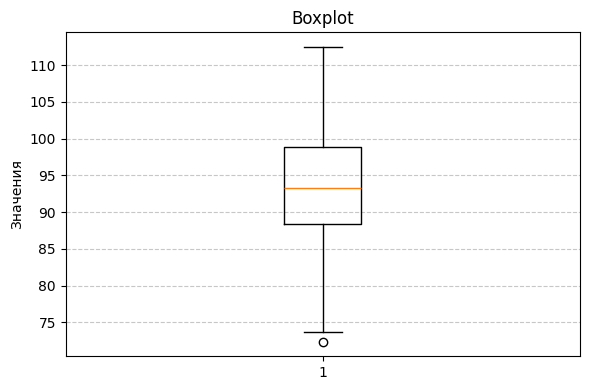

In [40]:
draw_boxplot(X)

Описание формы распределения:
- Распределение практически идеально симметрично. Среднее ($93.36$) и медиана ($93.27$) почти слились в одну точку.
- На boxplot виден один «одинокий» выброс снизу (в районе $72$), но он не сильно портит общую картину.
- Естественных границ не видно.

##### 2. Предположение о виде закона распределения

Лучшая модель для $X_3$ - **нормальное распределение $N_{a, \sigma}$.**

Гистограмма имеет ярко выраженную колоколовидную форму. Виден четкий бугор посередине. Совпадение среднего и медианы окончательно подтверждает симметричность, что подтверждает нормальность. Эмперическая функция распределения - сигмовидная =).

##### 3. Оценивание параметров: метод моментов и метод максимального правдоподобия

In [41]:
estimation_normal(X)

Метод моментов: $a = 93.3580, σ = 7.5008$

ММП: $a = 93.3580, σ = 7.5008$

Различие: $Δa = 0.0000, Δσ = 0.0000$

Для нормального закона формулы оценок среднего и стандартного отклонения в обоих методах математически совпадают.

##### 4. Оценивание параметрической вероятности двумя способами

In [42]:
prob_normal(X)

<IPython.core.display.Math object>

Эмпирическая вероятность: $\hat{P}(X > x_0) = 0.1600$

Параметрическая вероятность (нормальное): $P(X > x_0) = 0.1580$

Расхождение: $0.0020$

Минимальные расхождения подтверждают корректность модели.

##### 5. Оценка моментов по сгруппированной выборке

In [43]:
grouped_moments(X, 'fd')

Правило группировки: fd, число интервалов $m = 93$

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Группировка по Скотту и Фридману–Диаконису даёт неплохие результаты, так как разбивает на большее количество интервалов.

##### 6. Доверительные интервалы

In [44]:
asy_ci_mean(X)

Асимптотический $(\alpha = 0.95)$ ДИ для EX:

<IPython.core.display.Math object>

In [45]:
exact_ci_normal(X)

Точный $(\alpha = 0.95)$ ДИ для $\mu$ (неизвестный $\sigma^2$):

<IPython.core.display.Math object>

Точный $(\alpha = 0.95)$ ДИ для $\sigma^2$:

<IPython.core.display.Math object>

На 95% уверены, что истинное среднее значение всей генеральной совокупности находится в диапазоне примерно от 92.31 до 94.40.

Поскольку интервалы для среднего очень узкие (ширина всего около 2.1 при самом значении около 93), очень точно определился «центр» исследуемого процесса.

# Итоговый вывод по $X_1$, $X_2$ и $X_3$

**$X_1$ - Равномерное распределение $U_{a, b}$.**

Параметры: границы интервала примерно $[28.1, 114.3]$ (по ММП).

Практический вывод: процесс абсолютно стабилен и предсказуем в своих границах; любое значение внутри диапазона равновероятно. Это «белый шум» без выраженных всплесков или затиший.

**$X_2$ - Экспоненциальное распределение со сдвигом $Exp_{\lambda, c}$.**

Параметры: интенсивность $\lambda \approx 0.045$, сдвиг (минимум) $c = 9.2$.

Практический вывод: типичная модель «времени ожидания» или «износа». Большинство событий происходят быстро (сразу после порога 9.2), но есть длинный хвост редких, аномально больших значений.

**$X_3$ - Нормальное распределение $N_{a, \sigma}$.

Параметры: среднее значение $a \approx 93.36$, стандартное отклонение $\sigma \approx 7.5$.**

Практический вывод: классический случайный процесс. Ошибки или отклонения от центра в 93.36 симметричны и быстро затухают, что делает эту величину самой удобной для точного прогнозирования.

**Общий итог:** три принципиально разных типа случайности, все три модели подтверждены расчетами вероятностей с высокой точностью.

# Задание для $X_4$

In [46]:
X = sorted(X4)
n = len(X)
print('Объём выборки', n)
print('Вариационный ряд', X)

Объём выборки 200
Вариационный ряд [30.27, 30.28, 31.89, 33.49, 34.22, 34.46, 34.81, 35.02, 35.43, 35.44, 36.27, 36.35, 37.47, 37.7, 37.85, 37.9, 38.65, 38.73, 38.98, 39.38, 39.77, 39.97, 40.26, 40.47, 40.88, 40.89, 41.6, 41.65, 41.79, 42.18, 42.4, 42.55, 43.02, 43.53, 43.87, 44.15, 44.44, 44.45, 44.58, 44.58, 44.71, 44.77, 44.88, 44.98, 45.01, 45.31, 45.64, 46.25, 46.36, 46.67, 46.81, 47.23, 47.27, 47.35, 47.48, 47.82, 47.87, 48.36, 48.43, 48.61, 48.96, 49.65, 49.68, 49.95, 50.15, 50.2, 50.22, 50.45, 50.62, 50.71, 50.87, 51.12, 51.23, 51.71, 51.95, 53.07, 53.48, 53.58, 53.71, 53.78, 54.24, 54.49, 54.5, 55.14, 55.16, 55.46, 55.77, 55.89, 55.9, 56.61, 56.76, 56.94, 57.2, 57.28, 57.37, 57.53, 57.57, 58.08, 59.66, 59.79, 59.84, 60.26, 62.17, 62.42, 64.17, 64.25, 98.41, 104.44, 113.3, 114.57, 115.06, 115.96, 116.27, 116.54, 117.08, 117.27, 117.33, 118.53, 119.77, 120.05, 120.67, 120.68, 120.81, 120.84, 120.85, 120.94, 121.19, 121.38, 121.59, 121.66, 122.67, 122.68, 122.72, 123.19, 123.43, 

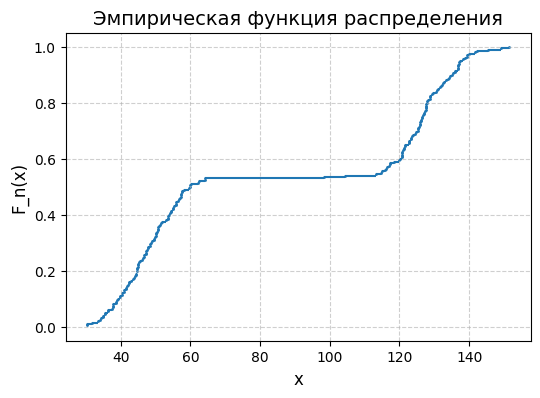

In [47]:
CDF_display(X)

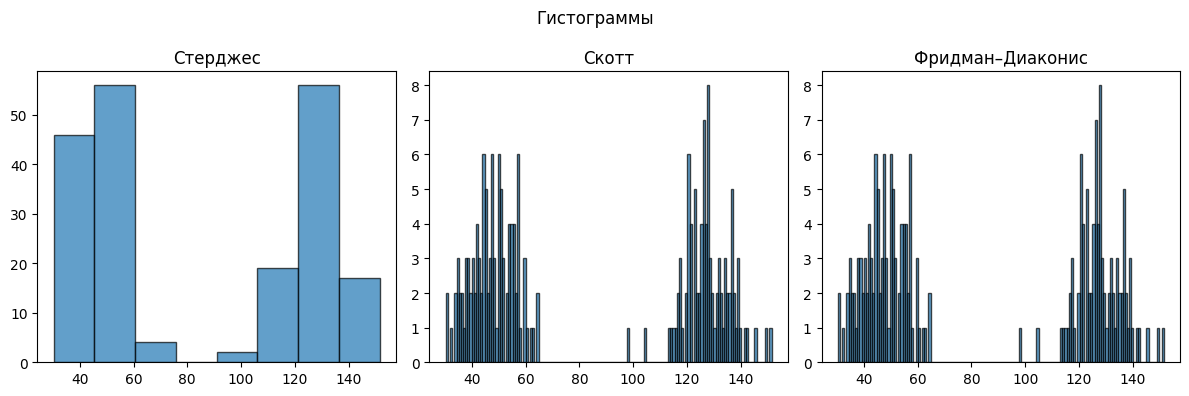

In [48]:
histogram(X)

In [49]:
characteristics(X)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

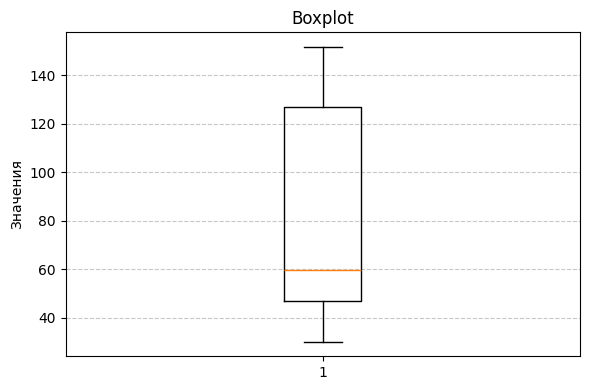

In [50]:
draw_boxplot(X)

- На гистограмме есть две отдельные вышки (в районе 50 и 130), а между ними — пустота. Это не одна выборка, а смесь двух разных групп.

- Ступенька на графике: ЭФР замирает в горизонтальном полете от 65 до 115. Это значит, что в этом диапазоне данных просто нет.

- Растянутый ящик: boxplot выглядит странно, потому что пытается охватить две кучки сразу, раздуваясь от 40 до 130.

In [51]:
def clusterise_half(X):
  centers1, centers2 = [min(X)], [max(X)]

  i = 0
  tol = 1e-12
  while True:
    cluster1 = [z for z in X if abs(z - centers1[i]) <= abs(z - centers2[i])]
    cluster2 = [z for z in X if abs(z - centers1[i]) > abs(z - centers2[i])]

    new_x = sum(cluster1) / len(cluster1) if cluster1 else centers1[i]
    new_y = sum(cluster2) / len(cluster2) if cluster2 else centers2[i]

    centers1.append(new_x)
    centers2.append(new_y)
    i += 1

    if abs(centers1[i] - centers1[i-1]) < tol and abs(centers2[i] - centers2[i-1]) < tol:
      break

  return cluster1, centers1[-1], cluster2, centers2[-1]

### Результаты кластеризации $X_4$

**Кластер 1** (Объём: 106)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

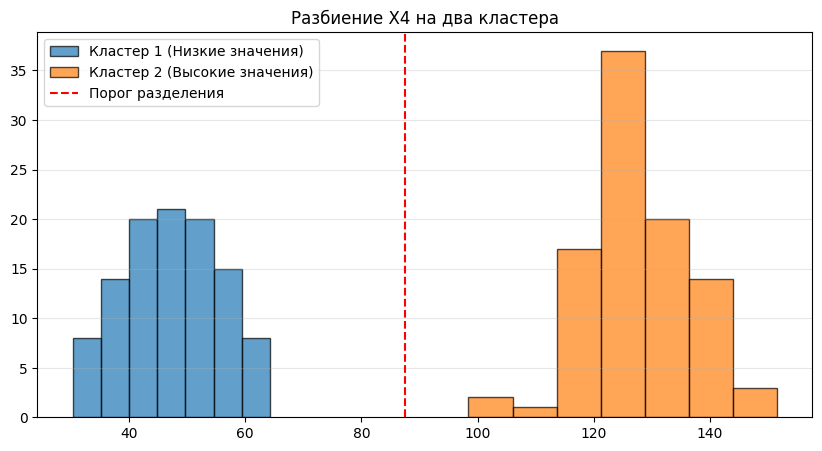

In [52]:
X_c1, X_m1, X_c2, X_m2 = clusterise_half(X)

display(Markdown("### Результаты кластеризации $X_4$"))

display(Markdown(f"**Кластер 1** (Объём: {len(X_c1)})"))
characteristics(X_c1)

display(Markdown(f"**Кластер 2** (Объём: {len(X_c2)})"))
characteristics(X_c2)

plt.figure(figsize=(10, 5))
plt.hist(X_c1, bins=sturges_rule(X_c1), alpha=0.7, label='Кластер 1 (Низкие значения)', edgecolor='black')
plt.hist(X_c2, bins=sturges_rule(X_c2), alpha=0.7, label='Кластер 2 (Высокие значения)', edgecolor='black')
plt.axvline((X_m1 + X_m2)/2, color='red', linestyle='--', label='Порог разделения')
plt.title("Разбиение X4 на два кластера")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

Общее среднее в такой ситуации оказывается в «мёртвой зоне» (около 90), где реальных данных практически нет, поэтому оно не представляет ни одну из групп. Вместо описания типичного значения выборки, оно просто усредняет два полярных режима, скрывая реальную структуру и бимодальность данных.